In [ ]:
# Hucre 1: Setup
from google.colab import drive
drive.mount('/content/drive')

!pip install -q segmentation-models-pytorch==0.3.4

import os, sys, time, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import segmentation_models_pytorch as smp

PROJECT = Path('/content/drive/MyDrive/DR_Project')
SRC = PROJECT / 'src'
IDRID_SEG = PROJECT / 'datasets' / 'IDRiD' / 'A. Segmentation'
SEG_CKPT = PROJECT / 'checkpoints' / 'best_segmenter.pth'
FIG = PROJECT / 'reports' / 'figures'

sys.path.insert(0, str(SRC))

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device('cuda')
print(f"Device: {device}")
print(f"segmentation_models_pytorch: {smp.__version__}")
print(f"IDRiD seg path var mi: {IDRID_SEG.exists()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 999, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 15, in <module>
    from pip._internal.cli.req_command import (
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 19, in <module>
    from pip._internal.index.package_finder import PackageFinder
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/index/package_finder.py", line 31, in <module>
    from pip._internal.req import Ins

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_8641/3351152283.py", line 5, in <cell line: 0>
    get_ipython().system('pip install -q segmentation-models-pytorch==0.3.4')
  File "/usr/local/lib/python3.12/dist-packages/google/colab/_shell.py", line 99, in system
    _pip.print_previous_import_warning(output)
  File "/usr/local/lib/python3.12/dist-packages/google/colab/_pip.py", line 56, in print_previous_import_warning
    packages = _previously_imported_packages(output)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/google/colab/_pip.py", line 50, in _previously_imported_packages
    installed = set(_extract_toplevel_packages(pip_output))
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/google/colab/_pip.

TypeError: object of type 'NoneType' has no len()

In [ ]:
# Hucre 2: IDRiD seg path map
TRAIN_IMG_DIR = IDRID_SEG / '1. Original Images' / 'a. Training Set'
TEST_IMG_DIR  = IDRID_SEG / '1. Original Images' / 'b. Testing Set'
TRAIN_GT_DIR  = IDRID_SEG / '2. All Segmentation Groundtruths' / 'a. Training Set'
TEST_GT_DIR   = IDRID_SEG / '2. All Segmentation Groundtruths' / 'b. Testing Set'

# Lezyon klasor adlari + suffixleri
LESION_INFO = {
    'MA': {'dir_name': '1. Microaneurysms',  'suffix': '_MA', 'name': 'Mikroanevrizma'},
    'HE': {'dir_name': '2. Haemorrhages',    'suffix': '_HE', 'name': 'Kanama'},
    'EX': {'dir_name': '3. Hard Exudates',   'suffix': '_EX', 'name': 'Sert Eksuda'},
    'SE': {'dir_name': '4. Soft Exudates',   'suffix': '_SE', 'name': 'Yumusak Eksuda'},
}
LESION_KEYS = list(LESION_INFO.keys())  # ['MA', 'HE', 'EX', 'SE']

def build_path_map(img_dir: Path, gt_dir: Path):
    """Her goruntu icin {goruntu_yolu, MA_maske, HE_maske, EX_maske, SE_maske}."""
    records = []
    for img_path in sorted(img_dir.glob('*.jpg')):
        stem = img_path.stem  # IDRiD_01
        rec = {'image_id': stem, 'image_path': str(img_path)}
        for key in LESION_KEYS:
            info = LESION_INFO[key]
            mask_path = gt_dir / info['dir_name'] / f"{stem}{info['suffix']}.tif"
            rec[f'mask_{key}'] = str(mask_path) if mask_path.exists() else None
        records.append(rec)
    return pd.DataFrame(records)

train_seg_df = build_path_map(TRAIN_IMG_DIR, TRAIN_GT_DIR)
test_seg_df  = build_path_map(TEST_IMG_DIR,  TEST_GT_DIR)

print(f"Train: {len(train_seg_df)} goruntu")
print(f"Test:  {len(test_seg_df)} goruntu\n")

# Hangi lezyonlar kac goruntude var?
print("Lezyon mevcudiyet (train):")
for key in LESION_KEYS:
    n = train_seg_df[f'mask_{key}'].notna().sum()
    print(f"  {LESION_INFO[key]['name']:20s} ({key}): {n}/{len(train_seg_df)}")

print("\nLezyon mevcudiyet (test):")
for key in LESION_KEYS:
    n = test_seg_df[f'mask_{key}'].notna().sum()
    print(f"  {LESION_INFO[key]['name']:20s} ({key}): {n}/{len(test_seg_df)}")

# Kaydet
SEG_SPLITS = PROJECT / 'splits'
train_seg_df.to_csv(SEG_SPLITS / 'seg_train.csv', index=False)
test_seg_df.to_csv(SEG_SPLITS / 'seg_test.csv', index=False)

print(f"\nCSV'ler: {SEG_SPLITS}/seg_train.csv, seg_test.csv")

# Hizli sanity: bir ornegi yukle
ex = train_seg_df.iloc[0]
img = np.array(Image.open(ex['image_path']))
print(f"\nOrnek goruntu: {ex['image_id']}")
print(f"  Shape: {img.shape}, dtype: {img.dtype}")
for key in LESION_KEYS:
    mp = ex[f'mask_{key}']
    if mp:
        m = np.array(Image.open(mp))
        print(f"  Mask {key}: {m.shape}, dtype={m.dtype}, min={m.min()}, max={m.max()}, "
              f"nonzero={int((m>0).sum())}")

In [ ]:
%%writefile /content/drive/MyDrive/DR_Project/src/seg_dataset.py
"""Lezyon segmentasyon dataseti (IDRiD)."""
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2

sys.path.insert(0, str(Path(__file__).parent))
from preprocessing import crop_fundus, apply_clahe, get_normalization_stats

LESION_KEYS = ['MA', 'HE', 'EX', 'SE']
LESION_NAMES = ['Mikroanevrizma', 'Kanama', 'Sert Eksuda', 'Yumusak Eksuda']
LESION_COLORS_RGB = [(255, 0, 0), (255, 140, 0), (255, 255, 0), (0, 200, 255)]


def get_seg_train_transforms(size: int = 512):
    """Multi-task: ayni transform hem image hem mask uygulanir."""
    stats = get_normalization_stats()
    return A.Compose([
        A.Resize(size, size, interpolation=cv2.INTER_AREA),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.Rotate(limit=180, border_mode=0, value=0, mask_value=0, p=0.6),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),
        A.Normalize(mean=stats['mean'], std=stats['std']),
        ToTensorV2(),
    ])


def get_seg_val_transforms(size: int = 512):
    stats = get_normalization_stats()
    return A.Compose([
        A.Resize(size, size, interpolation=cv2.INTER_AREA),
        A.Normalize(mean=stats['mean'], std=stats['std']),
        ToTensorV2(),
    ])


class IDRiDSegDataset(Dataset):
    """
    Cikti:
        image: tensor (3, H, W)
        mask:  tensor (4, H, W)  [MA, HE, EX, SE], her piksel 0/1
    """
    def __init__(self, csv_path, transform=None, apply_preprocess: bool = True):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.transform = transform
        self.apply_preprocess = apply_preprocess

    def __len__(self):
        return len(self.df)

    def _load_mask(self, path):
        """Maske yukle, 0/1 binary. Yoksa None doner."""
        if pd.isna(path) or path == '' or path is None:
            return None
        m = np.array(Image.open(path))
        if m.ndim == 3:
            m = m[..., 0]
        m = (m > 0).astype(np.uint8)
        return m

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = np.array(Image.open(row['image_path']).convert('RGB'))

        # 4 lezyon maskelerini stack et
        masks = []
        for key in LESION_KEYS:
            m = self._load_mask(row.get(f'mask_{key}'))
            if m is None:
                m = np.zeros(img.shape[:2], dtype=np.uint8)
            masks.append(m)
        mask = np.stack(masks, axis=-1)  # H x W x 4

        # Preprocess (crop + CLAHE) - opsiyonel
        if self.apply_preprocess:
            # crop_fundus: hem image hem mask icin ayni kirpma
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            m_fundus = gray > 7
            if m_fundus.sum() > 0:
                coords = np.argwhere(m_fundus)
                y0, x0 = coords.min(axis=0)
                y1, x1 = coords.max(axis=0) + 1
                img = img[y0:y1, x0:x1]
                mask = mask[y0:y1, x0:x1]
            img = apply_clahe(img)

        # Albumentations augmentation
        if self.transform is not None:
            aug = self.transform(image=img, mask=mask)
            img = aug['image']
            mask = aug['mask']  # H x W x 4 tensor
            # Albumentations mask'i (H, W, 4) tensor olarak verir, (4, H, W)'ye permute et
            if mask.ndim == 3 and mask.shape[-1] == 4:
                mask = mask.permute(2, 0, 1)
            mask = mask.float()

        return img, mask

In [ ]:
# Hucre 4: Seg dataset test + 1 ornegi gorsel kontrol
import importlib
import seg_dataset
importlib.reload(seg_dataset)
from seg_dataset import (IDRiDSegDataset, get_seg_train_transforms,
                         get_seg_val_transforms, LESION_KEYS, LESION_NAMES,
                         LESION_COLORS_RGB)

SEG_SIZE = 512  # segmentasyon icin yuksek cozunurluk

train_seg_ds = IDRiDSegDataset(
    PROJECT / 'splits' / 'seg_train.csv',
    transform=get_seg_train_transforms(SEG_SIZE),
    apply_preprocess=True,
)
test_seg_ds = IDRiDSegDataset(
    PROJECT / 'splits' / 'seg_test.csv',
    transform=get_seg_val_transforms(SEG_SIZE),
    apply_preprocess=True,
)

print(f"Train seg: {len(train_seg_ds)} | Test seg: {len(test_seg_ds)}")

# Tek ornek
img_t, mask_t = train_seg_ds[0]
print(f"\nImage tensor: shape={tuple(img_t.shape)}, dtype={img_t.dtype}, "
      f"min={img_t.min():.3f}, max={img_t.max():.3f}")
print(f"Mask  tensor: shape={tuple(mask_t.shape)}, dtype={mask_t.dtype}, "
      f"min={mask_t.min():.3f}, max={mask_t.max():.3f}")
print(f"Per-lezyon piksel sayisi: ", end='')
for i, key in enumerate(LESION_KEYS):
    print(f"{key}={int(mask_t[i].sum())}", end='  ')
print()

# Gorsel: image + 4 mask
stats = {'mean': [0.485,0.456,0.406], 'std':[0.229,0.224,0.225]}
def denorm(t):
    arr = t.permute(1,2,0).cpu().numpy()
    arr = arr * np.array(stats['std']) + np.array(stats['mean'])
    return np.clip(arr, 0, 1)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
axes[0].imshow(denorm(img_t))
axes[0].set_title('Image (preprocessed)'); axes[0].axis('off')
for i, (key, name, color) in enumerate(zip(LESION_KEYS, LESION_NAMES, LESION_COLORS_RGB)):
    m = mask_t[i].numpy()
    overlay = denorm(img_t).copy()
    overlay[m > 0.5] = np.array(color) / 255.0 * 0.7 + overlay[m > 0.5] * 0.3
    axes[i+1].imshow(overlay)
    axes[i+1].set_title(f'{name} ({key})\n{int(m.sum())} piksel')
    axes[i+1].axis('off')
plt.suptitle('Segmentasyon Dataset Sanity Check (Train, 1. ornek)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG / 'fig_seg_sanity.png', dpi=110, bbox_inches='tight')
plt.show()

In [ ]:
%%writefile /content/drive/MyDrive/DR_Project/src/seg_models.py
"""Lezyon segmentasyonu icin U-Net modelleri."""
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn


def create_segmenter(encoder_name: str = 'efficientnet-b0',
                     in_channels: int = 3,
                     n_classes: int = 4,
                     pretrained: bool = True):
    """
    U-Net + EfficientNet encoder (ImageNet pretrained).
    n_classes = 4: [MA, HE, EX, SE] multi-label segmentasyon.
    """
    model = smp.Unet(
        encoder_name=encoder_name,
        encoder_weights='imagenet' if pretrained else None,
        in_channels=in_channels,
        classes=n_classes,
        activation=None,  # logit, sigmoid loss icinde olacak
    )
    return model


class BCEDiceLoss(nn.Module):
    """
    BCE + Dice kombinasyonu. Multi-label segmentasyon icin standart.
    Her kanal (lezyon tipi) icin bagimsiz hesaplanir.
    """
    def __init__(self, bce_weight: float = 0.5, dice_weight: float = 0.5,
                 smooth: float = 1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_w = bce_weight
        self.dice_w = dice_weight
        self.smooth = smooth

    def dice_loss(self, logits, targets):
        probs = torch.sigmoid(logits)
        # her kanal icin ayri dice
        dims = (0, 2, 3)
        intersection = (probs * targets).sum(dims)
        union = probs.sum(dims) + targets.sum(dims)
        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1.0 - dice.mean()

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        dice = self.dice_loss(logits, targets)
        return self.bce_w * bce + self.dice_w * dice

In [ ]:
%%writefile /content/drive/MyDrive/DR_Project/src/seg_train_utils.py
"""Segmentasyon egitim ve degerlendirme yardimcilari."""
import time
import numpy as np
import torch
from torch.amp import autocast, GradScaler


def dice_per_channel(probs, targets, threshold: float = 0.5,
                     smooth: float = 1.0):
    """
    Her kanal (lezyon) icin Dice skoru hesapla.
    probs: (B, C, H, W) sigmoid sonrasi 0-1
    targets: (B, C, H, W) 0/1
    Donus: (C,) numpy
    """
    preds = (probs > threshold).float()
    dims = (0, 2, 3)
    intersection = (preds * targets).sum(dims)
    union = preds.sum(dims) + targets.sum(dims)
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return dice.cpu().numpy()


def iou_per_channel(probs, targets, threshold: float = 0.5,
                    smooth: float = 1.0):
    """Her kanal icin IoU."""
    preds = (probs > threshold).float()
    dims = (0, 2, 3)
    intersection = (preds * targets).sum(dims)
    union = preds.sum(dims) + targets.sum(dims) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou.cpu().numpy()


@torch.no_grad()
def evaluate_seg(model, loader, device, criterion=None):
    """Segmentation modeli degerlendir."""
    model.eval()
    all_probs, all_targets, total_loss = [], [], 0.0
    n_batches = 0
    for imgs, masks in loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        with autocast(device_type='cuda', dtype=torch.float16):
            logits = model(imgs)
            if criterion is not None:
                total_loss += criterion(logits.float(), masks).item()
                n_batches += 1
        probs = torch.sigmoid(logits.float())
        all_probs.append(probs.cpu())
        all_targets.append(masks.cpu())

    probs = torch.cat(all_probs, dim=0)
    targets = torch.cat(all_targets, dim=0)

    dice = dice_per_channel(probs, targets)
    iou  = iou_per_channel(probs, targets)
    return {
        'avg_loss': total_loss / max(1, n_batches),
        'dice_per_class': dice,
        'iou_per_class': iou,
        'dice_mean': float(dice.mean()),
        'iou_mean': float(iou.mean()),
    }


def train_seg_epoch(model, loader, criterion, optimizer, scaler, device,
                    epoch_idx, total_epochs, scheduler=None):
    model.train()
    total_loss, n = 0.0, 0
    t0 = time.time()
    for imgs, masks in loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type='cuda', dtype=torch.float16):
            logits = model(imgs)
            loss = criterion(logits.float(), masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item() * imgs.size(0)
        n += imgs.size(0)

    avg_loss = total_loss / n
    elapsed = time.time() - t0
    print(f"  Epoch {epoch_idx+1}/{total_epochs} | train_loss={avg_loss:.4f} | "
          f"{elapsed:.1f}s")
    return avg_loss

In [ ]:
# Hucre 6: Seg eitim setup
import importlib
import seg_dataset, seg_models, seg_train_utils
importlib.reload(seg_dataset); importlib.reload(seg_models); importlib.reload(seg_train_utils)

from seg_dataset import (IDRiDSegDataset, get_seg_train_transforms,
                         get_seg_val_transforms, LESION_KEYS, LESION_NAMES)
from seg_models import create_segmenter, BCEDiceLoss
from seg_train_utils import train_seg_epoch, evaluate_seg

# ============ HIPERPARAMETRELER ============
SEG_ENCODER  = 'efficientnet-b0'
SEG_SIZE     = 512
SEG_BATCH    = 4         # 54 ornek, 512x512, T4 12GB icin uygun
SEG_EPOCHS   = 60        # kucuk dataset, cok epoch
SEG_LR       = 1e-4
SEG_WD       = 1e-5
WARMUP_EP    = 3
N_CLASSES    = 4
# ===========================================

# Dataloaders
train_ds = IDRiDSegDataset(
    PROJECT / 'splits' / 'seg_train.csv',
    transform=get_seg_train_transforms(SEG_SIZE),
    apply_preprocess=True,
)
test_ds = IDRiDSegDataset(
    PROJECT / 'splits' / 'seg_test.csv',
    transform=get_seg_val_transforms(SEG_SIZE),
    apply_preprocess=True,
)

train_loader = DataLoader(train_ds, batch_size=SEG_BATCH, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=SEG_BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Test  batches: {len(test_loader)}")

# Model
seg_model = create_segmenter(encoder_name=SEG_ENCODER,
                              in_channels=3, n_classes=N_CLASSES,
                              pretrained=True).to(device)
n_params = sum(p.numel() for p in seg_model.parameters() if p.requires_grad)
print(f"\nModel: U-Net + {SEG_ENCODER}")
print(f"Parametre: {n_params/1e6:.2f}M")

# Loss + Optimizer + Scheduler
seg_criterion = BCEDiceLoss(bce_weight=0.5, dice_weight=0.5)
seg_optimizer = torch.optim.AdamW(seg_model.parameters(), lr=SEG_LR,
                                   weight_decay=SEG_WD)

total_steps = SEG_EPOCHS * len(train_loader)
warmup_steps = WARMUP_EP * len(train_loader)

def seg_lr_lambda(step):
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + np.cos(np.pi * progress))

seg_scheduler = torch.optim.lr_scheduler.LambdaLR(seg_optimizer, seg_lr_lambda)
seg_scaler = GradScaler()

print(f"\nLoss: BCE(0.5) + Dice(0.5)")
print(f"Optimizer: AdamW, LR={SEG_LR}, WD={SEG_WD}")
print(f"Scheduler: Warmup ({WARMUP_EP} ep) + Cosine")
print(f"Epochs: {SEG_EPOCHS}, Batch: {SEG_BATCH}")
print("\nSeg egitime hazir.")

In [ ]:
import torch
import segmentation_models_pytorch as smp
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'YOK'}")
print(f"smp: {smp.__version__}")

PyTorch: 2.10.0+cpu
CUDA available: False
GPU: YOK
smp: 0.3.4


In [1]:
# Mevcut CPU torch'u kaldir, CUDA versiyonuyla degistir
!pip uninstall -y torch torchvision torchaudio
!pip install -q torch==2.5.1 torchvision==0.20.1 --index-url https://download.pytorch.org/whl/cu121


Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 117.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 80.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 54.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 110.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━

In [1]:
# Hucre 1 (TEMIZ): Drive + smp --no-deps + setup
from google.colab import drive
drive.mount('/content/drive')

# smp'yi torch'a dokunmadan kur
!pip install -q --no-deps segmentation-models-pytorch==0.3.4
!pip install -q --no-deps pretrainedmodels efficientnet-pytorch

import torch
import segmentation_models_pytorch as smp
print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU:            {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'YOK'}")
print(f"smp:            {smp.__version__}")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
PyTorch:        2.5.1+cu121
CUDA available: True
GPU:            Tesla T4
smp:            0.3.4


In [2]:
# Hucre 2: Path setup + module imports + cache restore
import os, sys, time, json, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Yollar
PROJECT = Path('/content/drive/MyDrive/DR_Project')
IDRID = PROJECT / 'datasets' / 'IDRiD'
IDRID_SEG = IDRID / 'A. Segmentation'
SRC = PROJECT / 'src'
SPLITS = PROJECT / 'splits'
FIG = PROJECT / 'reports' / 'figures'
CHECKPOINTS = PROJECT / 'checkpoints'
CACHE = Path('/content/cache')

for d in [SRC, SPLITS, FIG, CHECKPOINTS]:
    d.mkdir(parents=True, exist_ok=True)

# Cache restore (sinif modeli icin gerekli degil ama hazir olsun)
TAR_BACKUP = PROJECT / 'cache_backup.tar'
CACHE_DIR_PNG = CACHE / 'preprocessed'
if not CACHE_DIR_PNG.exists() and TAR_BACKUP.exists():
    print(f"Cache restore: {TAR_BACKUP.stat().st_size/1e6:.0f} MB...")
    CACHE.mkdir(parents=True, exist_ok=True)
    subprocess.run(['tar', '-xf', str(TAR_BACKUP), '-C', str(CACHE)], check=True)
    print(f"  {len(list(CACHE_DIR_PNG.glob('*.png')))} PNG restore edildi")
else:
    print("Cache zaten var veya restore gerekmiyor (seg icin gerekli degil)")

# Albumentations da gerek
!pip install -q --no-deps albumentations==1.4.18
import albumentations as A
print(f"albumentations: {A.__version__}")

# Module yollari
sys.path.insert(0, str(SRC))

# Seed
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

print(f"\nSrc icerigi:")
for f in sorted(SRC.glob('*.py')):
    print(f"  {f.name}")

Device: cuda
Cache restore: 748 MB...
  4075 PNG restore edildi
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.0/224.0 kB 10.7 MB/s eta 0:00:00
albumentations: 1.4.18

Src icerigi:
  dataset.py
  models.py
  preprocessing.py
  seg_dataset.py
  seg_models.py
  seg_train_utils.py
  train_utils.py


/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [3]:
# Hucre 3: Seg setup (path map, dataloaders, model, optimizer)
import importlib
import preprocessing, seg_dataset, seg_models, seg_train_utils
for m in [preprocessing, seg_dataset, seg_models, seg_train_utils]:
    importlib.reload(m)

from seg_dataset import (IDRiDSegDataset, get_seg_train_transforms,
                         get_seg_val_transforms, LESION_KEYS, LESION_NAMES,
                         LESION_COLORS_RGB)
from seg_models import create_segmenter, BCEDiceLoss
from seg_train_utils import train_seg_epoch, evaluate_seg

# Path map (daha onceki keseflerden bildigimiz yapi)
TRAIN_IMG_DIR = IDRID_SEG / '1. Original Images' / 'a. Training Set'
TEST_IMG_DIR  = IDRID_SEG / '1. Original Images' / 'b. Testing Set'
TRAIN_GT_DIR  = IDRID_SEG / '2. All Segmentation Groundtruths' / 'a. Training Set'
TEST_GT_DIR   = IDRID_SEG / '2. All Segmentation Groundtruths' / 'b. Testing Set'

LESION_INFO = {
    'MA': {'dir_name': '1. Microaneurysms',  'suffix': '_MA'},
    'HE': {'dir_name': '2. Haemorrhages',    'suffix': '_HE'},
    'EX': {'dir_name': '3. Hard Exudates',   'suffix': '_EX'},
    'SE': {'dir_name': '4. Soft Exudates',   'suffix': '_SE'},
}

def build_path_map(img_dir, gt_dir):
    rows = []
    for img_path in sorted(img_dir.glob('*.jpg')):
        stem = img_path.stem
        r = {'image_id': stem, 'image_path': str(img_path)}
        for key, info in LESION_INFO.items():
            mp = gt_dir / info['dir_name'] / f"{stem}{info['suffix']}.tif"
            r[f'mask_{key}'] = str(mp) if mp.exists() else None
        rows.append(r)
    return pd.DataFrame(rows)

train_seg_df = build_path_map(TRAIN_IMG_DIR, TRAIN_GT_DIR)
test_seg_df  = build_path_map(TEST_IMG_DIR,  TEST_GT_DIR)
train_seg_df.to_csv(SPLITS / 'seg_train.csv', index=False)
test_seg_df.to_csv(SPLITS / 'seg_test.csv', index=False)
print(f"Train: {len(train_seg_df)} | Test: {len(test_seg_df)}")

# ============ HIPERPARAMETRELER ============
SEG_ENCODER  = 'efficientnet-b0'
SEG_SIZE     = 512
SEG_BATCH    = 4
SEG_EPOCHS   = 60
SEG_LR       = 1e-4
SEG_WD       = 1e-5
WARMUP_EP    = 3
N_CLASSES    = 4
# ===========================================

# Datasets + Loaders
train_ds = IDRiDSegDataset(SPLITS / 'seg_train.csv',
                            transform=get_seg_train_transforms(SEG_SIZE),
                            apply_preprocess=True)
test_ds  = IDRiDSegDataset(SPLITS / 'seg_test.csv',
                            transform=get_seg_val_transforms(SEG_SIZE),
                            apply_preprocess=True)
train_loader = DataLoader(train_ds, batch_size=SEG_BATCH, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_ds, batch_size=SEG_BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

# Model + Loss + Optimizer + Scheduler
seg_model = create_segmenter(encoder_name=SEG_ENCODER, in_channels=3,
                              n_classes=N_CLASSES, pretrained=True).to(device)
n_params = sum(p.numel() for p in seg_model.parameters() if p.requires_grad)
print(f"Model: U-Net + {SEG_ENCODER} | {n_params/1e6:.2f}M parametre")

seg_criterion = BCEDiceLoss(bce_weight=0.5, dice_weight=0.5)
seg_optimizer = torch.optim.AdamW(seg_model.parameters(), lr=SEG_LR,
                                   weight_decay=SEG_WD)

total_steps = SEG_EPOCHS * len(train_loader)
warmup_steps = WARMUP_EP * len(train_loader)
def seg_lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

seg_scheduler = torch.optim.lr_scheduler.LambdaLR(seg_optimizer, seg_lr_lambda)
seg_scaler = GradScaler()

# Hizli sanity check: 1 batch GPU'ya gonder
img_t, mask_t = next(iter(train_loader))
img_t = img_t.to(device); mask_t = mask_t.to(device)
with autocast(device_type='cuda', dtype=torch.float16):
    logits = seg_model(img_t)
print(f"\nSanity check:")
print(f"  Image: {tuple(img_t.shape)} on {img_t.device}")
print(f"  Mask:  {tuple(mask_t.shape)}")
print(f"  Logits:{tuple(logits.shape)}")
print(f"\nEgitime hazir. {SEG_EPOCHS} epoch, ~{SEG_EPOCHS * 30 / 60:.0f} dakika tahmini.")

Train: 54 | Test: 27
Train batches: 13 | Test batches: 7


Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth
100%|██████████| 20.4M/20.4M [00:00<00:00, 140MB/s]


Model: U-Net + efficientnet-b0 | 6.25M parametre

Sanity check:
  Image: (4, 3, 512, 512) on cuda:0
  Mask:  (4, 4, 512, 512)
  Logits:(4, 4, 512, 512)

Egitime hazir. 60 epoch, ~30 dakika tahmini.


In [4]:
# Hucre 4: Segmentasyon egitimi
seg_history = {
    'train_loss': [],
    'test_loss': [],
    'test_dice_mean': [],
    'test_iou_mean': [],
    'test_dice_per_class': [],
    'test_iou_per_class': [],
    'lr': [],
}

seg_ckpt = CHECKPOINTS / 'best_segmenter.pth'
best_dice = -1.0
best_ep = -1

print("="*60)
print(f"Segmentasyon egitimi: {SEG_EPOCHS} epoch")
print("="*60)
t_global = time.time()

for epoch in range(SEG_EPOCHS):
    # Train
    tr_loss = train_seg_epoch(
        seg_model, train_loader, seg_criterion, seg_optimizer,
        seg_scaler, device, epoch, SEG_EPOCHS, scheduler=seg_scheduler,
    )
    # Val (test set kullaniyoruz, klasik IDRiD protokolu)
    val_m = evaluate_seg(seg_model, test_loader, device, criterion=seg_criterion)
    current_lr = seg_optimizer.param_groups[0]['lr']

    seg_history['train_loss'].append(tr_loss)
    seg_history['test_loss'].append(val_m['avg_loss'])
    seg_history['test_dice_mean'].append(val_m['dice_mean'])
    seg_history['test_iou_mean'].append(val_m['iou_mean'])
    seg_history['test_dice_per_class'].append(val_m['dice_per_class'].tolist())
    seg_history['test_iou_per_class'].append(val_m['iou_per_class'].tolist())
    seg_history['lr'].append(current_lr)

    print(f"           val_loss={val_m['avg_loss']:.4f} | "
          f"mean_dice={val_m['dice_mean']:.4f} | "
          f"per_class={[f'{x:.3f}' for x in val_m['dice_per_class']]}")

    if val_m['dice_mean'] > best_dice:
        best_dice = val_m['dice_mean']
        best_ep = epoch + 1
        torch.save({
            'epoch': epoch + 1,
            'model_state': seg_model.state_dict(),
            'metrics': {
                'dice_mean': float(val_m['dice_mean']),
                'iou_mean': float(val_m['iou_mean']),
                'dice_per_class': val_m['dice_per_class'].tolist(),
                'iou_per_class': val_m['iou_per_class'].tolist(),
            },
            'config': {'encoder': SEG_ENCODER, 'size': SEG_SIZE,
                       'n_classes': N_CLASSES, 'lesion_keys': LESION_KEYS},
        }, seg_ckpt)
        print(f"           >>> Best mean_dice={best_dice:.4f} (epoch {best_ep}) kaydedildi")

elapsed = (time.time() - t_global) / 60
print(f"\n{'='*60}")
print(f"Egitim tamam: {elapsed:.1f} dakika")
print(f"Best epoch: {best_ep} | Best mean Dice: {best_dice:.4f}")
print(f"Checkpoint: {seg_ckpt}")
print(f"{'='*60}")

# History kaydet
with open(PROJECT / 'reports' / 'segmenter_history.json', 'w') as f:
    json.dump(seg_history, f, indent=2)
print(f"History: {PROJECT / 'reports' / 'segmenter_history.json'}")

Segmentasyon egitimi: 60 epoch
  Epoch 1/60 | train_loss=0.8342 | 90.0s
           val_loss=1.0088 | mean_dice=0.0127 | per_class=['0.003', '0.029', '0.015', '0.004']
           >>> Best mean_dice=0.0127 (epoch 1) kaydedildi
  Epoch 2/60 | train_loss=0.8225 | 39.7s
           val_loss=0.8864 | mean_dice=0.0164 | per_class=['0.002', '0.031', '0.027', '0.005']
           >>> Best mean_dice=0.0164 (epoch 2) kaydedildi
  Epoch 3/60 | train_loss=0.8036 | 38.4s
           val_loss=0.8116 | mean_dice=0.0179 | per_class=['0.002', '0.026', '0.038', '0.006']
           >>> Best mean_dice=0.0179 (epoch 3) kaydedildi
  Epoch 4/60 | train_loss=0.7776 | 37.7s
           val_loss=0.7679 | mean_dice=0.0142 | per_class=['0.002', '0.015', '0.033', '0.007']
  Epoch 5/60 | train_loss=0.7536 | 37.8s
           val_loss=0.7332 | mean_dice=0.0138 | per_class=['0.001', '0.014', '0.030', '0.010']
  Epoch 6/60 | train_loss=0.7349 | 37.3s
           val_loss=0.6949 | mean_dice=0.0167 | per_class=['0.001', '0.018

Best model yuklendi (epoch 60)
Metrikler: {'dice_mean': 0.3645058274269104, 'iou_mean': 0.24359488487243652, 'dice_per_class': [0.00012245897960383445, 0.46263641119003296, 0.5933454036712646, 0.4019189476966858], 'iou_per_class': [0.00012245897960383445, 0.30093058943748474, 0.421814888715744, 0.2515115439891815]}

=== FINAL TEST (IDRiD) ===
Loss: 0.5258
Mean Dice: 0.3645 | Mean IoU: 0.2436
  MA (Mikroanevrizma    ): Dice=0.0001  IoU=0.0001
  HE (Kanama            ): Dice=0.4626  IoU=0.3009
  EX (Sert Eksuda       ): Dice=0.5933  IoU=0.4218
  SE (Yumusak Eksuda    ): Dice=0.4019  IoU=0.2515


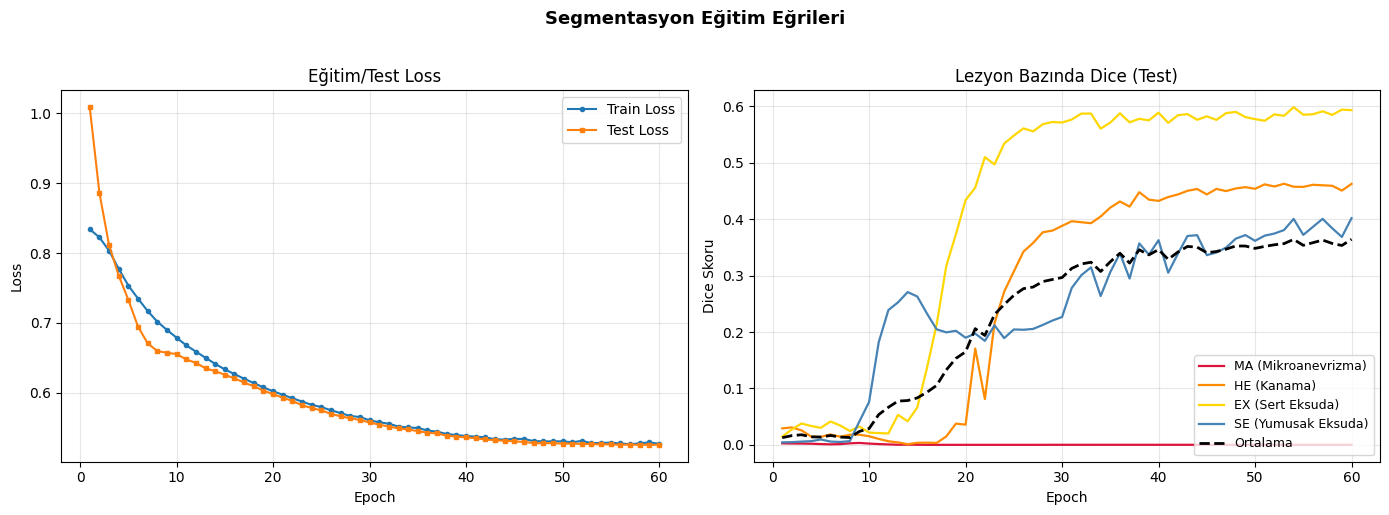

Kaydedildi: fig_seg_training_curves.png


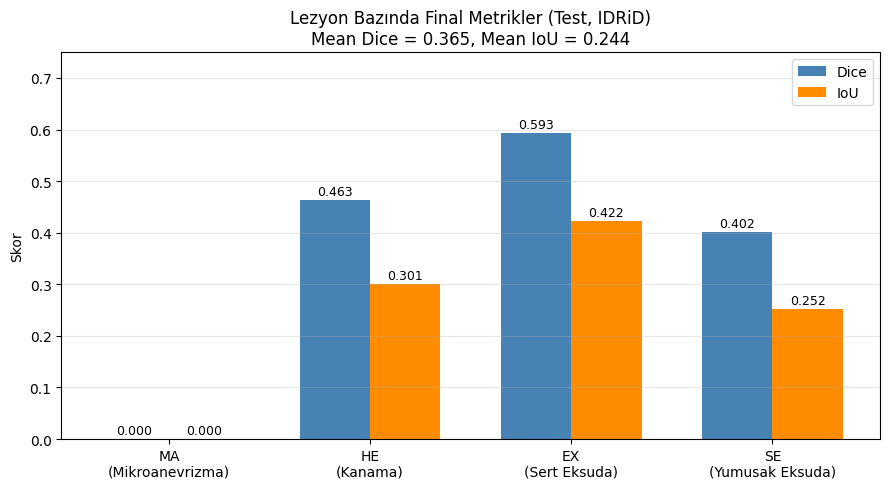

Kaydedildi: fig_seg_per_class_metrics.png


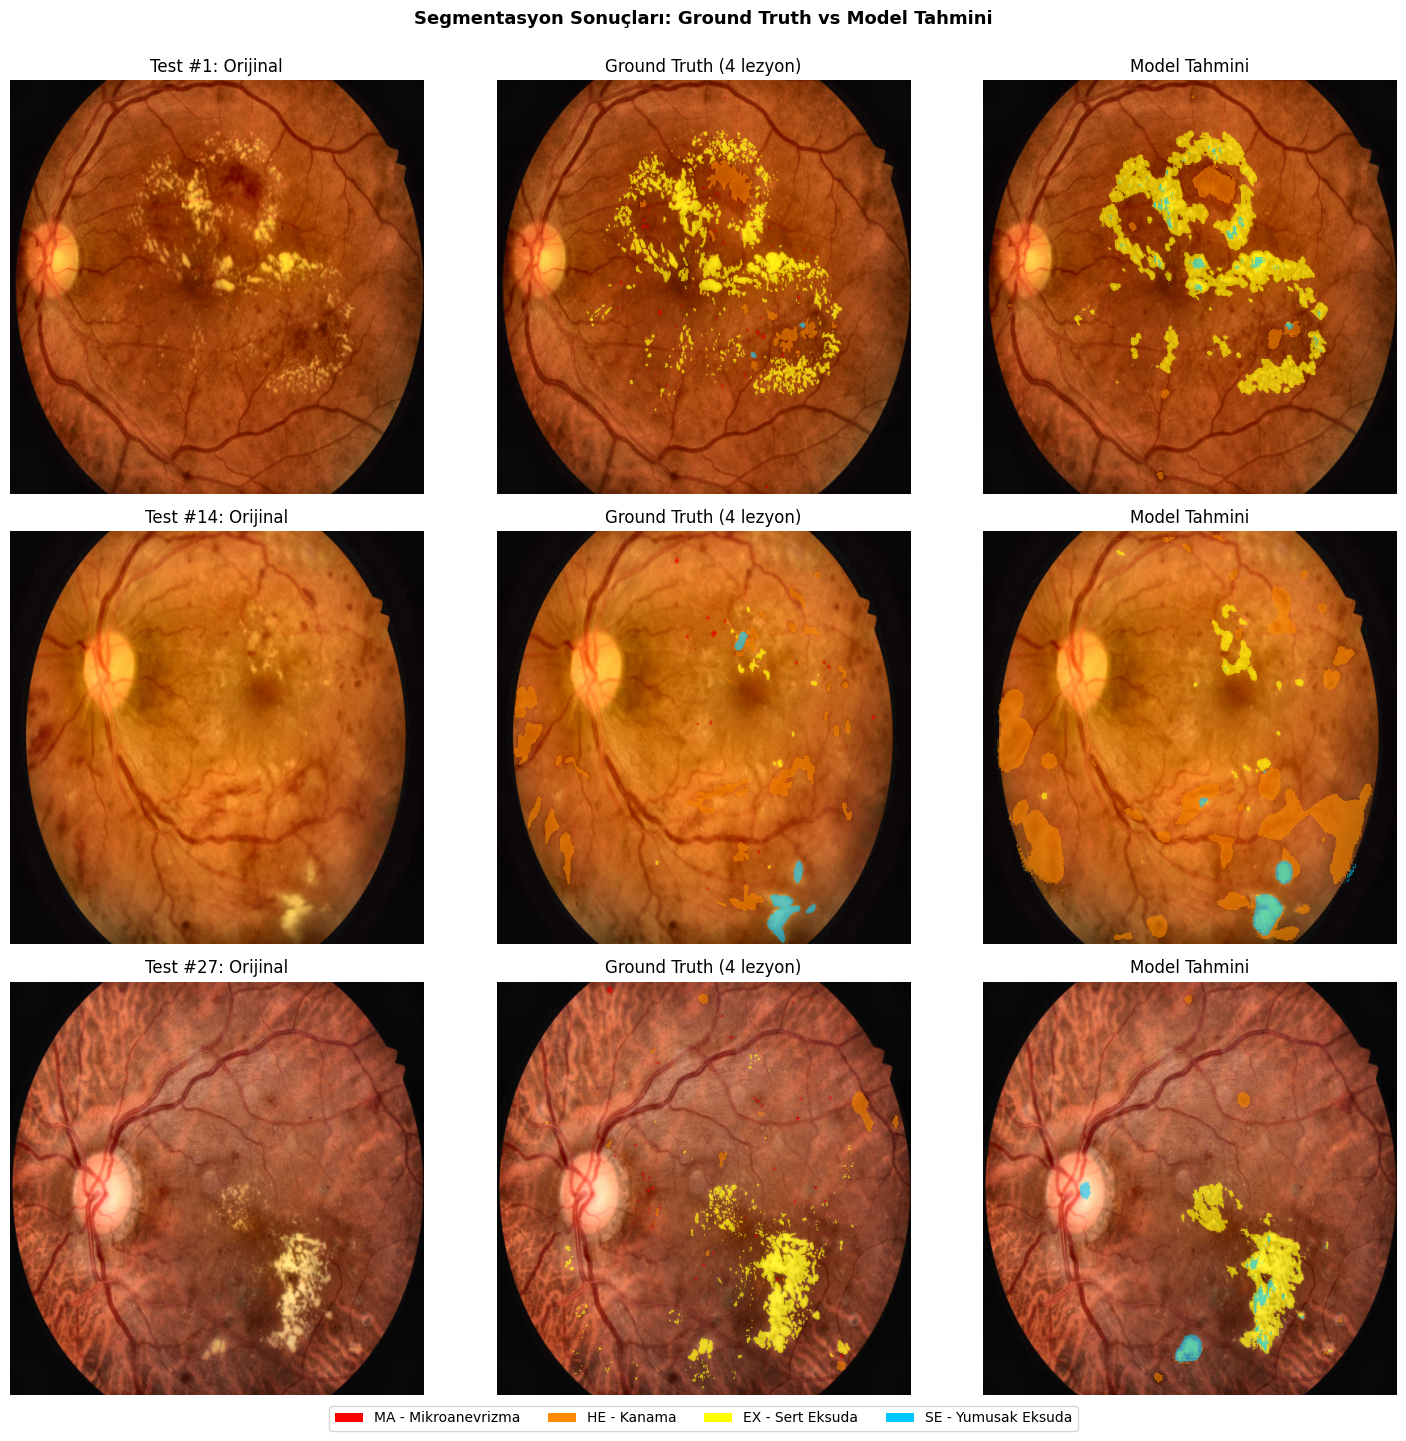

Kaydedildi: fig_seg_predictions.png

Tum metrikler: /content/drive/MyDrive/DR_Project/reports/segmenter_final_metrics.json


In [5]:
# Hucre 5: Seg evaluation + figurler
import json

# Best modeli yukle
ck = torch.load(seg_ckpt, map_location=device, weights_only=False)
seg_model.load_state_dict(ck['model_state'])
seg_model.eval()
print(f"Best model yuklendi (epoch {ck['epoch']})")
print(f"Metrikler: {ck['metrics']}")

# Final test degerlendirme
final_m = evaluate_seg(seg_model, test_loader, device, criterion=seg_criterion)
print(f"\n=== FINAL TEST (IDRiD) ===")
print(f"Loss: {final_m['avg_loss']:.4f}")
print(f"Mean Dice: {final_m['dice_mean']:.4f} | Mean IoU: {final_m['iou_mean']:.4f}")
for i, key in enumerate(LESION_KEYS):
    print(f"  {key} ({LESION_NAMES[i]:18s}): "
          f"Dice={final_m['dice_per_class'][i]:.4f}  "
          f"IoU={final_m['iou_per_class'][i]:.4f}")

# Sonuc dosyasi
seg_results = {
    'best_epoch': int(ck['epoch']),
    'mean_dice': float(final_m['dice_mean']),
    'mean_iou': float(final_m['iou_mean']),
    'per_class_dice': {k: float(v) for k, v in zip(LESION_KEYS, final_m['dice_per_class'])},
    'per_class_iou':  {k: float(v) for k, v in zip(LESION_KEYS, final_m['iou_per_class'])},
}
with open(PROJECT / 'reports' / 'segmenter_final_metrics.json', 'w') as f:
    json.dump(seg_results, f, indent=2)

# ============ FIGUR: Egitim egrileri (loss + per-class dice) ============
with open(PROJECT / 'reports' / 'segmenter_history.json') as f:
    hist = json.load(f)

epochs_x = list(range(1, len(hist['train_loss']) + 1))
per_class = np.array(hist['test_dice_per_class'])  # (epochs, 4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(epochs_x, hist['train_loss'], 'o-', label='Train Loss', ms=3)
ax.plot(epochs_x, hist['test_loss'],  's-', label='Test Loss', ms=3)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Eğitim/Test Loss'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
colors = ['crimson', 'darkorange', 'gold', 'steelblue']
for i, (key, color) in enumerate(zip(LESION_KEYS, colors)):
    ax.plot(epochs_x, per_class[:, i], '-', label=f'{key} ({LESION_NAMES[i]})',
            color=color, linewidth=1.6)
ax.plot(epochs_x, hist['test_dice_mean'], 'k--', linewidth=2, label='Ortalama')
ax.set_xlabel('Epoch'); ax.set_ylabel('Dice Skoru')
ax.set_title('Lezyon Bazında Dice (Test)')
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Segmentasyon Eğitim Eğrileri', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG / 'fig_seg_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("Kaydedildi: fig_seg_training_curves.png")

# ============ FIGUR: Per-class final bar chart ============
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(LESION_KEYS))
w = 0.35
ax.bar(x - w/2, final_m['dice_per_class'], w, label='Dice', color='steelblue')
ax.bar(x + w/2, final_m['iou_per_class'],  w, label='IoU',  color='darkorange')
for i, (d, j) in enumerate(zip(final_m['dice_per_class'], final_m['iou_per_class'])):
    ax.text(i - w/2, d + 0.01, f'{d:.3f}', ha='center', fontsize=9)
    ax.text(i + w/2, j + 0.01, f'{j:.3f}', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([f'{k}\n({n})' for k, n in zip(LESION_KEYS, LESION_NAMES)])
ax.set_ylabel('Skor')
ax.set_title(f'Lezyon Bazında Final Metrikler (Test, IDRiD)\n'
             f'Mean Dice = {final_m["dice_mean"]:.3f}, Mean IoU = {final_m["iou_mean"]:.3f}')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 0.75)
plt.tight_layout()
plt.savefig(FIG / 'fig_seg_per_class_metrics.png', dpi=120, bbox_inches='tight')
plt.show()
print("Kaydedildi: fig_seg_per_class_metrics.png")

# ============ FIGUR: 3 ornek goruntu icin tahmin overlay ============
seg_model.eval()
stats = {'mean': [0.485,0.456,0.406], 'std':[0.229,0.224,0.225]}
def denorm(t):
    arr = t.permute(1,2,0).cpu().numpy()
    arr = arr * np.array(stats['std']) + np.array(stats['mean'])
    return np.clip(arr, 0, 1)

# 3 farkli ornek sec (test set'ten)
sample_indices = [0, len(test_ds)//2, len(test_ds)-1]
fig, axes = plt.subplots(3, 3, figsize=(15, 14))

with torch.no_grad():
    for row_idx, samp in enumerate(sample_indices):
        img_t, mask_t = test_ds[samp]
        x = img_t.unsqueeze(0).to(device)
        with autocast(device_type='cuda', dtype=torch.float16):
            logits = seg_model(x)
        probs = torch.sigmoid(logits.float()).cpu().numpy()[0]  # (4, H, W)
        pred = (probs > 0.5).astype(np.uint8)
        gt = mask_t.numpy()  # (4, H, W)

        img_rgb = denorm(img_t)

        # Renkler MA=kirmizi, HE=turuncu, EX=sari, SE=mavi
        colors_n = [(1, 0, 0), (1, 0.55, 0), (1, 1, 0), (0, 0.78, 1)]

        def overlay(img, mask4, alpha=0.6):
            out = img.copy()
            for i, c in enumerate(colors_n):
                m = mask4[i] > 0.5
                out[m] = np.array(c) * alpha + out[m] * (1 - alpha)
            return out

        axes[row_idx, 0].imshow(img_rgb)
        axes[row_idx, 0].set_title(f'Test #{samp+1}: Orijinal')
        axes[row_idx, 1].imshow(overlay(img_rgb, gt))
        axes[row_idx, 1].set_title('Ground Truth (4 lezyon)')
        axes[row_idx, 2].imshow(overlay(img_rgb, pred))
        axes[row_idx, 2].set_title('Model Tahmini')
        for a in axes[row_idx]:
            a.axis('off')

# Renk legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_n[i], label=f'{LESION_KEYS[i]} - {LESION_NAMES[i]}')
                   for i in range(4)]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Segmentasyon Sonuçları: Ground Truth vs Model Tahmini',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(FIG / 'fig_seg_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print("Kaydedildi: fig_seg_predictions.png")

print(f"\nTum metrikler: {PROJECT / 'reports' / 'segmenter_final_metrics.json'}")